# 04 — 99,477-Parameter Neuromorphic Sleep Student
## Complete architecture → training → evaluation → graphs → statistics

This is the **single-file runnable experiment** for the 99,477-parameter Student.

It contains the complete model architecture, sequence dataset, training loop, checkpointing, test evaluation, plots, class statistics, confusion matrix, and result export.

### Architecture
`10 × 30 s PSG epochs → Lite Multi-Resolution Stem → Depthwise-Separable CNN → Parametric Gabor FEB → 272-dim Feature Fusion → 2-Layer GRU → 5-Class Head`

### Contract
- Input: `[B, 10, 4, 3000]`
- Context: 300 seconds
- Sampling rate: 100 Hz
- Classes: Wake / N1 / N2 / N3 / REM
- Trainable parameters: **99,477**
- Training: supervised class-weighted cross-entropy
- No Teacher model or distillation dependency

> This notebook retrains the 99,477-parameter architecture. A fresh run is not expected to numerically reproduce a previous benchmark unless the full historical training conditions are identical.

In [1]:
!pip install torch

In [2]:
import os, json, math, time, random, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR

from sklearn.metrics import (
    accuracy_score, cohen_kappa_score, f1_score,
    confusion_matrix, classification_report
)

SEED = 42
SEQ_LEN = 10
SEQ_STRIDE = 5
EPOCHS = 20
BATCH_SIZE = 16
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0

N_CHANNELS = 4
N_CLASSES = 5
FS = 100
EPOCH_SECONDS = 30
SAMPLES_PER_EPOCH = FS * EPOCH_SECONDS
STAGE_NAMES = ["Wake", "N1", "N2", "N3", "REM"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def find_project_root():
    candidates = [Path.cwd(), Path("/home/shamique/projects/sleep"), Path("/workspace/sleep")]
    for start in candidates:
        for p in [start, *start.parents]:
            if (p / "data" / "cache" / "cache_index.csv").exists():
                return p
            if (p / "data" / "cache" / "sleep_edf" / "cache_index.csv").exists():
                return p
    return Path.cwd()

PROJECT_ROOT = find_project_root()

if (PROJECT_ROOT / "data" / "cache" / "cache_index.csv").exists():
    CACHE_DIR = PROJECT_ROOT / "data" / "cache"
elif (PROJECT_ROOT / "data" / "cache" / "sleep_edf" / "cache_index.csv").exists():
    CACHE_DIR = PROJECT_ROOT / "data" / "cache" / "sleep_edf"
else:
    raise FileNotFoundError(
        "Could not find cache_index.csv. Run this notebook from the prepared repository."
    )

MANIFEST_PATH = PROJECT_ROOT / "data" / "manifests" / "exhibition_15subj_v1.json"
if not MANIFEST_PATH.exists():
    raise FileNotFoundError(f"Missing manifest: {MANIFEST_PATH}")

ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "standalone_99k"
RESULTS_DIR = PROJECT_ROOT / "results" / "standalone_99k"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = ARTIFACT_DIR / "student_99477_best.pt"
HISTORY_PATH = RESULTS_DIR / "training_history.csv"
METRICS_PATH = RESULTS_DIR / "test_metrics.json"
CLASS_REPORT_PATH = RESULTS_DIR / "classification_report.csv"
CONFUSION_PATH = RESULTS_DIR / "confusion_matrix.csv"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Project root:", PROJECT_ROOT)
print("Cache dir:   ", CACHE_DIR)
print("Manifest:    ", MANIFEST_PATH)
print("Device:      ", DEVICE)

Project root: /home/shamique/projects/sleep
Cache dir:    /home/shamique/projects/sleep/data/cache
Manifest:     /home/shamique/projects/sleep/data/manifests/exhibition_15subj_v1.json
Device:       cuda


## 1. Sequence dataset

Each sample is a contiguous 10-epoch sequence. Windows are generated inside each subject/night cache and the exhibition subject manifest is used as the split source of truth.

In [3]:
class SleepSequenceDataset(Dataset):
    def __init__(self, cache_index_df, seq_len=SEQ_LEN, stride=SEQ_STRIDE):
        self.samples = []
        self.cache = {}
        self.seq_len = seq_len

        for _, row in cache_index_df.iterrows():
            path = Path(row["cache_path"])
            if not path.is_absolute():
                path = PROJECT_ROOT / path
            path = str(path)
            if not Path(path).exists():
                raise FileNotFoundError(path)

            with np.load(path) as data:
                n = len(data["labels"])
            for start in range(0, n - seq_len + 1, stride):
                self.samples.append((path, start))

    def _load(self, path):
        if path not in self.cache:
            with np.load(path) as data:
                epochs = data["epochs"].astype(np.float32)
                labels = data["labels"].astype(np.int64)
                orig_idx = data["orig_epoch_idx"].copy() if "orig_epoch_idx" in data else None
            self.cache[path] = (epochs, labels, orig_idx)
        return self.cache[path]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        path, start = self.samples[index]
        epochs, labels, orig_idx = self._load(path)
        end = min(start + self.seq_len, len(labels))
        x = epochs[start:end]
        y = labels[start:end]

        if len(x) < self.seq_len:
            pad = self.seq_len - len(x)
            x = np.concatenate([x, np.repeat(x[-1:], pad, axis=0)], axis=0)
            y = np.concatenate([y, np.repeat(y[-1:], pad, axis=0)], axis=0)

        if orig_idx is not None:
            window_idx = orig_idx[start:end]
            if len(window_idx) > 1 and not np.all(np.diff(window_idx) == 1):
                raise ValueError(f"Temporal gap in {path} at start={start}")

        expected = (self.seq_len, N_CHANNELS, SAMPLES_PER_EPOCH)
        if tuple(x.shape) != expected:
            raise ValueError(f"Shape {x.shape} != expected {expected}")

        return torch.from_numpy(x), torch.from_numpy(y)

cache_index = pd.read_csv(CACHE_DIR / "cache_index.csv")
with open(MANIFEST_PATH) as f:
    manifest = json.load(f)

train_subjects = list(manifest["train_subjects"])
val_subjects = list(manifest["validation_subjects"])
test_subjects = list(manifest["test_subjects"])

assert set(train_subjects).isdisjoint(val_subjects)
assert set(train_subjects).isdisjoint(test_subjects)
assert set(val_subjects).isdisjoint(test_subjects)

def filter_cache(subjects):
    return cache_index.loc[cache_index["subject_id"].isin(subjects)].copy()

train_cache = filter_cache(train_subjects)
val_cache = filter_cache(val_subjects)
test_cache = filter_cache(test_subjects)

train_ds = SleepSequenceDataset(train_cache)
val_ds = SleepSequenceDataset(val_cache)
test_ds = SleepSequenceDataset(test_cache)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Subjects:", len(train_subjects), "train |", len(val_subjects), "val |", len(test_subjects), "test")
print("Windows: ", len(train_ds), "train |", len(val_ds), "val |", len(test_ds), "test")

Subjects: 70 train | 15 val | 15 test
Windows:  31667 train | 7154 val | 7486 test


## 2. Complete 99,477-parameter Student architecture

The architecture is embedded here rather than imported from `src/`, so this notebook is the single executable artifact.

The repository's current configuration documents the 99,477-parameter Student as 4 channels, 5 classes, 100 Hz, stem width 8, encoder `(32, 32)`, 8 Gabor filters, 16-D Gabor projection, 64-hidden 2-layer GRU, sequence length 10, and 51-sample Gabor kernels. citeturn891542view0

In [4]:
GABOR_FREQ_MIN_HZ = 0.5
GABOR_FREQ_MAX_HZ = 30.0

class StudentConfig:
    n_channels = 4
    n_classes = 5
    sampling_rate = 100
    gru_hidden = 64
    gru_layers = 2
    stem_width = 8
    encoder_channels = (32, 32)
    gabor_n_filters = 8
    gabor_out_dim = 16
    seq_len = 10
    epoch_seconds = 30
    gabor_kernel_size = 51

    @property
    def samples_per_epoch(self):
        return self.epoch_seconds * self.sampling_rate

class ImprovedStudent(nn.Module):
    def __init__(self, config=None):
        super().__init__()
        self.config = config or StudentConfig()
        stem_w = self.config.stem_width

        self.stem_s = nn.Sequential(
            nn.Conv1d(self.config.n_channels, stem_w, 25, stride=6, bias=False),
            nn.BatchNorm1d(stem_w),
        )
        self.stem_l = nn.Sequential(
            nn.Conv1d(self.config.n_channels, stem_w, 200, stride=25, bias=False),
            nn.BatchNorm1d(stem_w),
        )

        enc_c = self.config.encoder_channels
        stem_concat = 2 * stem_w
        self.enc = nn.ModuleDict({
            "0": nn.ModuleDict({
                "dw": nn.Conv1d(stem_concat, stem_concat, 5, stride=2, padding=2,
                                groups=stem_concat, bias=False),
                "pw": nn.Conv1d(stem_concat, enc_c[0], 1, bias=False),
                "bn": nn.BatchNorm1d(enc_c[0]),
            }),
            "1": nn.ModuleDict({
                "dw": nn.Conv1d(enc_c[0], enc_c[0], 5, stride=2, padding=2,
                                groups=enc_c[0], bias=False),
                "pw": nn.Conv1d(enc_c[0], enc_c[1], 1, bias=False),
                "bn": nn.BatchNorm1d(enc_c[1]),
            }),
        })

        self.pool = nn.AdaptiveAvgPool1d(8)

        n_f = self.config.gabor_n_filters
        legacy_freq_hz = torch.linspace(GABOR_FREQ_MIN_HZ, GABOR_FREQ_MAX_HZ, n_f)
        freq_frac = (legacy_freq_hz - GABOR_FREQ_MIN_HZ) / (
            GABOR_FREQ_MAX_HZ - GABOR_FREQ_MIN_HZ
        )
        self.gabor_freq_raw = nn.Parameter(torch.logit(freq_frac.clamp(1e-4, 1 - 1e-4)))

        sigma_legacy = torch.full((n_f,), 0.02)
        self.gabor_sigma_raw = nn.Parameter(torch.log(torch.expm1(sigma_legacy)))

        self.gab_proj = nn.Linear(n_f, self.config.gabor_out_dim)

        self.feature_dim = enc_c[1] * 8 + self.config.gabor_out_dim
        self.gru = nn.GRU(
            self.feature_dim,
            self.config.gru_hidden,
            num_layers=self.config.gru_layers,
            batch_first=True,
        )
        self.head = nn.Linear(self.config.gru_hidden, self.config.n_classes)

    @property
    def gabor_freq_hz(self):
        frac = torch.sigmoid(self.gabor_freq_raw)
        return GABOR_FREQ_MIN_HZ + frac * (GABOR_FREQ_MAX_HZ - GABOR_FREQ_MIN_HZ)

    @property
    def gabor_sigma(self):
        return F.softplus(self.gabor_sigma_raw) + 1e-4

    def forward(self, x, return_features=False):
        expected = (
            self.config.seq_len,
            self.config.n_channels,
            self.config.samples_per_epoch,
        )
        if x.ndim != 4:
            raise ValueError(f"Expected [B,T,C,S], got {tuple(x.shape)}")
        if tuple(x.shape[1:]) != expected:
            raise ValueError(f"Expected [B,{expected[0]},{expected[1]},{expected[2]}], got {tuple(x.shape)}")
        if not torch.isfinite(x).all():
            raise ValueError("Input contains NaN/Inf")

        b, t, c, s = x.shape
        flat = x.reshape(b * t, c, s)

        short = F.relu6(self.stem_s[1](self.stem_s[0](flat)))
        long = F.relu6(self.stem_l[1](self.stem_l[0](flat)))
        target = min(short.shape[-1], long.shape[-1])
        short = F.adaptive_avg_pool1d(short, target)
        long = F.adaptive_avg_pool1d(long, target)
        stem_out = torch.cat([short, long], dim=1)

        e0 = F.relu6(self.enc["0"]["bn"](
            self.enc["0"]["pw"](self.enc["0"]["dw"](stem_out))
        ))
        e1 = F.relu6(self.enc["1"]["bn"](
            self.enc["1"]["pw"](self.enc["1"]["dw"](e0))
        ))

        cnn = self.pool(e1).flatten(1)

        k = self.config.gabor_kernel_size
        t_axis = torch.arange(
            -(k // 2), k // 2 + 1, dtype=torch.float32, device=x.device
        ).unsqueeze(0)
        f0 = (self.gabor_freq_hz / self.config.sampling_rate).unsqueeze(1)
        sigma = self.gabor_sigma.unsqueeze(1)

        envelope = torch.exp(-0.5 * (t_axis / (sigma * k)) ** 2)
        carrier = torch.cos(2 * math.pi * f0 * t_axis)
        kernels = (envelope * carrier).unsqueeze(1)

        x_mean = flat.mean(dim=1, keepdim=True)
        gab = F.conv1d(x_mean, kernels, padding=k // 2)
        gab = F.adaptive_avg_pool1d(gab, 1).squeeze(-1)
        gab = self.gab_proj(gab)

        features = torch.cat([cnn, gab], dim=-1).reshape(b, t, self.feature_dim)
        sequence_out, _ = self.gru(features)
        logits = self.head(sequence_out)

        if return_features:
            return logits, features
        return logits

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [5]:
model = ImprovedStudent().to(DEVICE)
n_params = count_parameters(model)

print(f"Trainable parameters: {n_params:,}")
assert n_params == 99_477, f"Expected 99,477 parameters, got {n_params:,}"

with torch.no_grad():
    smoke = torch.randn(2, SEQ_LEN, N_CHANNELS, SAMPLES_PER_EPOCH, device=DEVICE)
    logits, features = model(smoke, return_features=True)

print("Input:    ", tuple(smoke.shape))
print("Features: ", tuple(features.shape))
print("Logits:   ", tuple(logits.shape))
print("Gabor Hz: ",
      np.round(model.gabor_freq_hz.detach().cpu().numpy(), 3).tolist())

assert tuple(features.shape) == (2, 10, 272)
assert tuple(logits.shape) == (2, 10, 5)

Trainable parameters: 99,477


Input:     (2, 10, 4, 3000)
Features:  (2, 10, 272)
Logits:    (2, 10, 5)
Gabor Hz:  [0.503000020980835, 4.714000225067139, 8.928999900817871, 13.142999649047852, 17.35700035095215, 21.570999145507812, 25.785999298095703, 29.996999740600586]


In [6]:
rows = []
for name, module in model.named_modules():
    direct = sum(p.numel() for p in module.parameters(recurse=False))
    if direct:
        rows.append({
            "module": name or "<root>",
            "type": module.__class__.__name__,
            "parameters": direct,
        })
arch_df = pd.DataFrame(rows).sort_values("parameters", ascending=False).reset_index(drop=True)
display(arch_df)
print(f"Total: {n_params:,} trainable parameters")
print(f"Feature dimension before GRU: {model.feature_dim}")

,module,type,parameters
0,gru,GRU,89856
1,stem_l.0,Conv1d,6400
2,enc.1.pw,Conv1d,1024
3,stem_s.0,Conv1d,800
4,enc.0.pw,Conv1d,512
5,head,Linear,325
6,enc.1.dw,Conv1d,160
7,gab_proj,Linear,144
8,enc.0.dw,Conv1d,80
9,enc.0.bn,BatchNorm1d,64


Total: 99,477 trainable parameters
Feature dimension before GRU: 272


## 3. Training class statistics

Class weights use only the training partition.

In [7]:
train_labels = []
for _, row in train_cache.iterrows():
    path = Path(row["cache_path"])
    if not path.is_absolute():
        path = PROJECT_ROOT / path
    with np.load(path) as data:
        train_labels.append(data["labels"])

train_labels = np.concatenate(train_labels)
class_counts = np.bincount(train_labels, minlength=N_CLASSES)

counts = torch.tensor(class_counts, dtype=torch.float32, device=DEVICE)
class_weights = torch.log(counts.sum() / (counts + 1.0))
class_weights = class_weights / class_weights.mean()

class_stats = pd.DataFrame({
    "stage": STAGE_NAMES,
    "count": class_counts,
    "percentage": class_counts / class_counts.sum() * 100,
    "weight": class_weights.detach().cpu().numpy(),
})
display(class_stats.style.format({"percentage": "{:.2f}%", "weight": "{:.4f}"}))

,stage,count,percentage,weight
0,Wake,110364,69.49%,0.1603
1,N1,7787,4.90%,1.3278
2,N2,25268,15.91%,0.8095
3,N3,5525,3.48%,1.4789
4,REM,9866,6.21%,1.2236


## 4. Training

In [8]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

def cosine_warmup(optimizer, total_steps, warmup_fraction=0.10):
    warmup_steps = max(1, int(total_steps * warmup_fraction))
    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * progress))
    return LambdaLR(optimizer, lr_lambda)

@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    ys, ps = [], []
    for x, y in loader:
        logits = model(x.to(DEVICE))
        pred = logits.argmax(dim=-1).cpu().numpy()
        ys.append(y.numpy().reshape(-1))
        ps.append(pred.reshape(-1))
    return np.concatenate(ys), np.concatenate(ps)

@torch.no_grad()
def eval_metrics(model, loader):
    y_true, y_pred = collect_predictions(model, loader)
    return {
        "kappa": cohen_kappa_score(y_true, y_pred),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

def save_checkpoint(model, epoch, metrics):
    payload = {
        "model_state_dict": model.state_dict(),
        "epoch": epoch,
        "metrics": metrics,
        "seed": SEED,
        "sequence_length": SEQ_LEN,
        "stride": SEQ_STRIDE,
        "sampling_rate": FS,
        "n_channels": N_CHANNELS,
        "n_classes": N_CLASSES,
        "parameter_count": n_params,
        "feature_dim": model.feature_dim,
        "architecture": "Lite Multi-Resolution Stem -> Depthwise-Separable CNN -> Gabor FEB -> 272-dim fusion -> 2-layer GRU -> 5-class head",
        "training": "supervised class-weighted cross-entropy",
    }
    try:
        payload["git_commit"] = subprocess.check_output(
            ["git", "rev-parse", "HEAD"], cwd=PROJECT_ROOT, text=True,
            stderr=subprocess.DEVNULL
        ).strip()
    except Exception:
        payload["git_commit"] = "unknown"
    torch.save(payload, CHECKPOINT_PATH)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = cosine_warmup(optimizer, EPOCHS * len(train_loader))

best_kappa = -np.inf
history = []
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    loss_sum, n_batches = 0.0, 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits.reshape(-1, N_CLASSES), y.reshape(-1))
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        loss_sum += float(loss.detach())
        n_batches += 1

    train_loss = loss_sum / max(n_batches, 1)
    vm = eval_metrics(model, val_loader)

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_kappa": vm["kappa"],
        "val_accuracy": vm["accuracy"],
        "val_macro_f1": vm["macro_f1"],
        "val_weighted_f1": vm["weighted_f1"],
        "learning_rate": optimizer.param_groups[0]["lr"],
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | loss={train_loss:.4f} | "
        f"kappa={vm['kappa']:.4f} | acc={vm['accuracy']:.4f} | "
        f"macro-F1={vm['macro_f1']:.4f}"
    )

    if vm["kappa"] > best_kappa:
        best_kappa = vm["kappa"]
        save_checkpoint(model, epoch, vm)
        print(f"  ✓ saved best checkpoint → {CHECKPOINT_PATH}")

training_seconds = time.time() - t0
history = pd.DataFrame(history)
history.to_csv(HISTORY_PATH, index=False)

print(f"\nTraining time: {training_seconds/60:.2f} min")
print(f"Best validation kappa: {history['val_kappa'].max():.4f}")

Epoch 01/20 | loss=1.1494 | kappa=0.7215 | acc=0.8603 | macro-F1=0.6107
  ✓ saved best checkpoint → /home/shamique/projects/sleep/artifacts/standalone_99k/student_99477_best.pt


Epoch 02/20 | loss=0.6736 | kappa=0.7762 | acc=0.8892 | macro-F1=0.6901
  ✓ saved best checkpoint → /home/shamique/projects/sleep/artifacts/standalone_99k/student_99477_best.pt


Epoch 03/20 | loss=0.5400 | kappa=0.8038 | acc=0.9000 | macro-F1=0.7385
  ✓ saved best checkpoint → /home/shamique/projects/sleep/artifacts/standalone_99k/student_99477_best.pt


Epoch 04/20 | loss=0.4687 | kappa=0.7977 | acc=0.8974 | macro-F1=0.7443


Epoch 05/20 | loss=0.4385 | kappa=0.8195 | acc=0.9093 | macro-F1=0.7535
  ✓ saved best checkpoint → /home/shamique/projects/sleep/artifacts/standalone_99k/student_99477_best.pt


...

Epoch 17/20 | loss=0.2902 | kappa=0.8178 | acc=0.9081 | macro-F1=0.7651


Epoch 18/20 | loss=0.2852 | kappa=0.8274 | acc=0.9128 | macro-F1=0.7701
  ✓ saved best checkpoint → /home/shamique/projects/sleep/artifacts/standalone_99k/student_99477_best.pt


Epoch 19/20 | loss=0.2829 | kappa=0.8232 | acc=0.9109 | macro-F1=0.7661


Epoch 20/20 | loss=0.2797 | kappa=0.8219 | acc=0.9099 | macro-F1=0.7665



Training time: 18.15 min
Best validation kappa: 0.8274


## 5. Load best checkpoint and evaluate on test set

In [9]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
best_model = ImprovedStudent().to(DEVICE)
best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

print("Best epoch:", checkpoint["epoch"])
print("Best validation metrics:", checkpoint["metrics"])
print("Parameter count:", checkpoint["parameter_count"])

y_true, y_pred = collect_predictions(best_model, test_loader)

test_metrics = {
    "accuracy": float(accuracy_score(y_true, y_pred)),
    "cohen_kappa": float(cohen_kappa_score(y_true, y_pred)),
    "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    "n_labels": int(len(y_true)),
    "parameter_count": int(n_params),
    "training_seconds": float(training_seconds),
}

display(pd.DataFrame({
    "metric": ["Accuracy", "Cohen's kappa", "Macro F1", "Weighted F1", "Test labels", "Parameters"],
    "value": [
        test_metrics["accuracy"], test_metrics["cohen_kappa"],
        test_metrics["macro_f1"], test_metrics["weighted_f1"],
        test_metrics["n_labels"], test_metrics["parameter_count"],
    ],
}))

report_dict = classification_report(
    y_true, y_pred,
    labels=list(range(N_CLASSES)),
    target_names=STAGE_NAMES,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).T.reset_index().rename(columns={"index": "class"})
display(report_df)

cm = confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES)))
cm_df = pd.DataFrame(cm, index=STAGE_NAMES, columns=STAGE_NAMES)

print("Confusion matrix:")
display(cm_df)

with open(METRICS_PATH, "w") as f:
    json.dump(test_metrics, f, indent=2)

report_df.to_csv(CLASS_REPORT_PATH, index=False)
cm_df.to_csv(CONFUSION_PATH)

Best epoch: 18
Best validation metrics: {'kappa': 0.8274039393884121, 'accuracy': 0.9128180039138943, 'macro_f1': 0.7701183664890898, 'weighted_f1': 0.9169390227754847}
Parameter count: 99477


,metric,value
0,Accuracy,0.905651
1,Cohen's kappa,0.807961
2,Macro F1,0.748988
3,Weighted F1,0.911545
4,Test labels,74860.000000
5,Parameters,99477.000000


,class,precision,recall,f1-score,support
0,Wake,0.995901,0.960793,0.978032,52593.000000
1,N1,0.386795,0.622029,0.476986,2524.000000
2,N2,0.819026,0.826061,0.822528,11642.000000
3,N3,0.617425,0.822545,0.705376,2688.000000
4,REM,0.816206,0.714576,0.762017,5413.000000
5,accuracy,0.905651,0.905651,0.905651,0.905651
6,macro avg,0.727070,0.789201,0.748988,74860.000000
7,weighted avg,0.921273,0.905651,0.911545,74860.000000


Confusion matrix:


,Wake,N1,N2,N3,REM
Wake,50531,1248,190,160,464
N1,112,1570,653,19,170
N2,9,627,9617,1153,236
N3,1,10,465,2211,1
REM,86,604,817,38,3868


## 6. Graphs

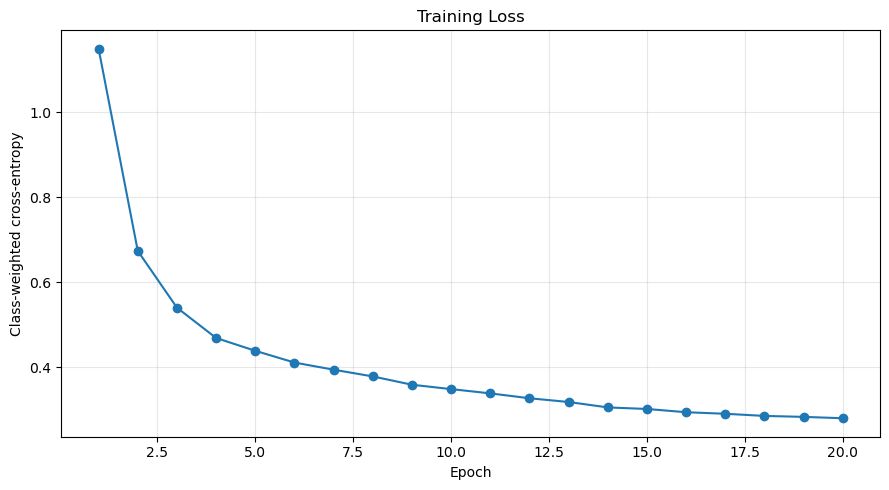

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history["epoch"], history["train_loss"], marker="o")
ax.set_title("Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Class-weighted cross-entropy")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_loss.png", dpi=180, bbox_inches="tight")
plt.show()

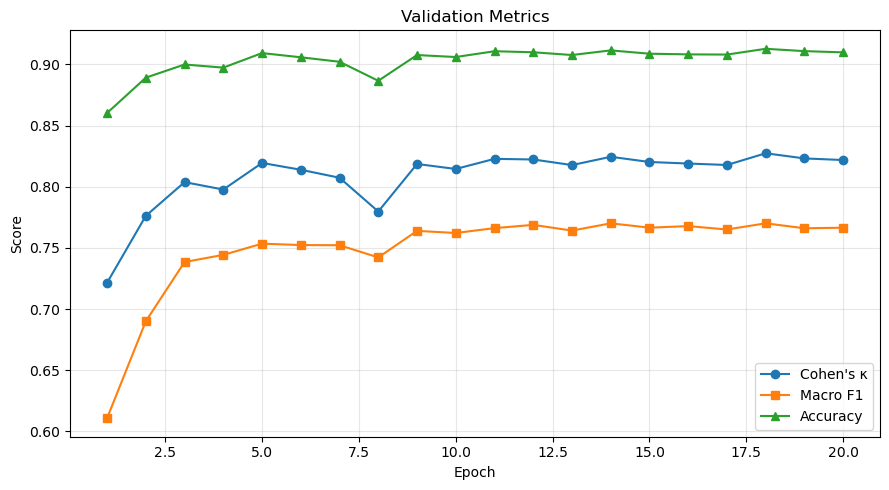

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history["epoch"], history["val_kappa"], marker="o", label="Cohen's κ")
ax.plot(history["epoch"], history["val_macro_f1"], marker="s", label="Macro F1")
ax.plot(history["epoch"], history["val_accuracy"], marker="^", label="Accuracy")
ax.set_title("Validation Metrics")
ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "validation_metrics.png", dpi=180, bbox_inches="tight")
plt.show()

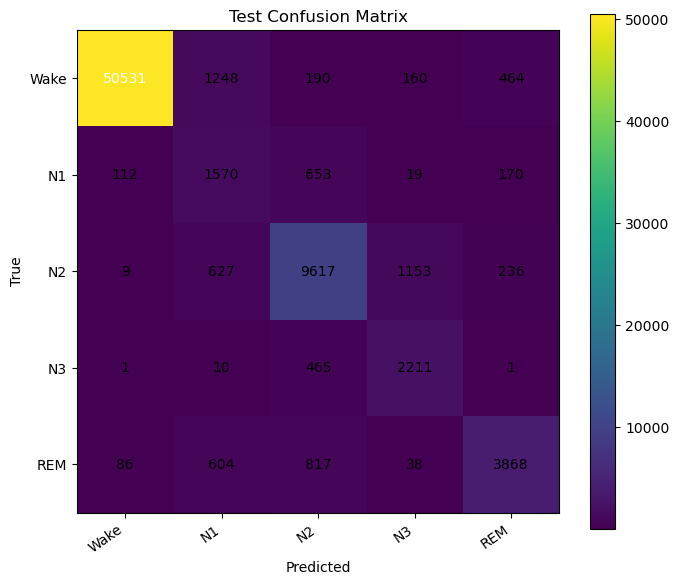

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm)
fig.colorbar(im, ax=ax)
ax.set_xticks(range(N_CLASSES))
ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(STAGE_NAMES, rotation=35, ha="right")
ax.set_yticklabels(STAGE_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Test Confusion Matrix")

threshold = cm.max() / 2 if cm.max() else 0
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(
            j, i, str(int(cm[i, j])),
            ha="center", va="center",
            color="white" if cm[i, j] > threshold else "black"
        )

plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

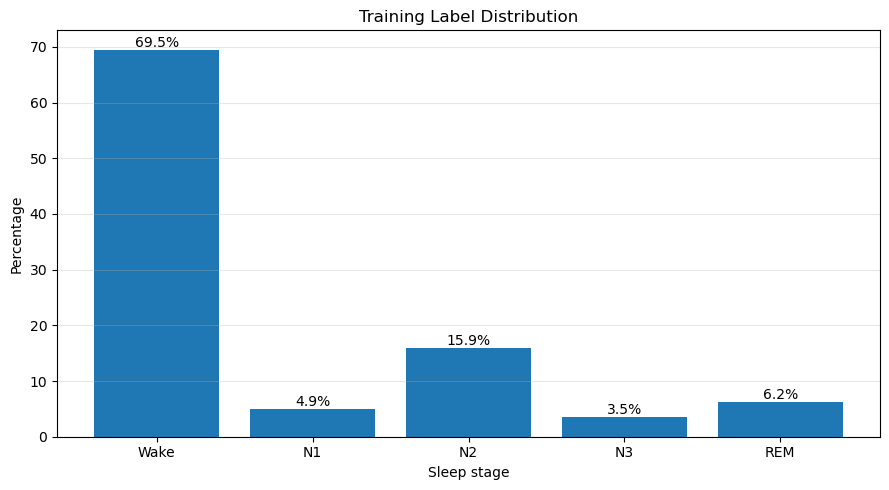

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(class_stats["stage"], class_stats["percentage"])
ax.set_title("Training Label Distribution")
ax.set_xlabel("Sleep stage")
ax.set_ylabel("Percentage")
ax.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, class_stats["percentage"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.1f}%",
            ha="center", va="bottom")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_class_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

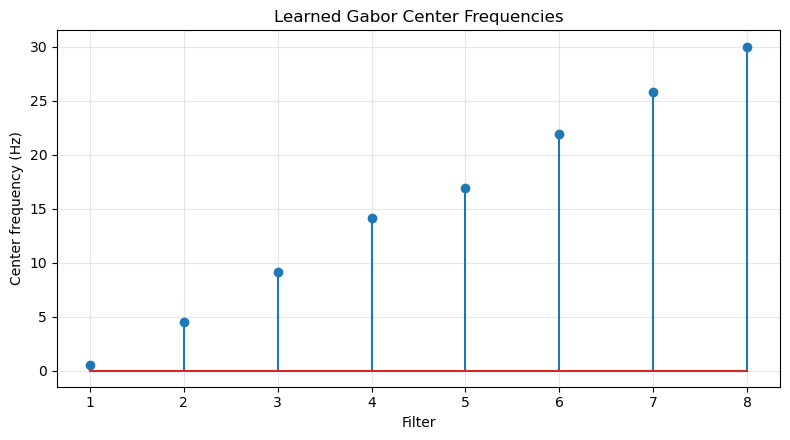

Gabor frequencies (Hz): [0.503000020980835, 4.448999881744385, 9.144000053405762, 14.116000175476074, 16.93400001525879, 21.910999298095703, 25.809999465942383, 29.996999740600586]


In [14]:
gabor_freqs = best_model.gabor_freq_hz.detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.stem(range(1, len(gabor_freqs) + 1), gabor_freqs)
ax.set_title("Learned Gabor Center Frequencies")
ax.set_xlabel("Filter")
ax.set_ylabel("Center frequency (Hz)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "learned_gabor_frequencies.png", dpi=180, bbox_inches="tight")
plt.show()

print("Gabor frequencies (Hz):", np.round(gabor_freqs, 3).tolist())

## 7. Final result bundle

At the end of this notebook the complete experiment is saved under:

```text
artifacts/standalone_99k/
└── student_99477_best.pt

results/standalone_99k/
├── training_history.csv
├── test_metrics.json
├── classification_report.csv
├── confusion_matrix.csv
├── training_loss.png
├── validation_metrics.png
├── confusion_matrix.png
├── training_class_distribution.png
└── learned_gabor_frequencies.png
```

In [15]:
summary = {
    "architecture": {
        "parameters": int(n_params),
        "input_shape": [1, SEQ_LEN, N_CHANNELS, SAMPLES_PER_EPOCH],
        "context_seconds": SEQ_LEN * EPOCH_SECONDS,
        "feature_dim": int(best_model.feature_dim),
        "gru_hidden": best_model.config.gru_hidden,
        "gru_layers": best_model.config.gru_layers,
        "gabor_filters": best_model.config.gabor_n_filters,
        "gabor_output_dim": best_model.config.gabor_out_dim,
        "classes": STAGE_NAMES,
    },
    "training": {
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "seed": SEED,
        "device": str(DEVICE),
        "training_seconds": training_seconds,
        "best_validation_epoch": int(checkpoint["epoch"]),
        "best_validation_kappa": float(checkpoint["metrics"]["kappa"]),
    },
    "test": test_metrics,
}

with open(RESULTS_DIR / "experiment_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

{
  "architecture": {
    "parameters": 99477,
    "input_shape": [
      1,
      10,
      4,
      3000
    ],
    "context_seconds": 300,
    "feature_dim": 272,
    "gru_hidden": 64,
    "gru_layers": 2,
    "gabor_filters": 8,
    "gabor_output_dim": 16,
    "classes": [
      "Wake",
      "N1",
      "N2",
      "N3",
      "REM"
    ]
  },
  "training": {
    "epochs": 20,
    "batch_size": 16,
    "learning_rate": 0.0003,
    "weight_decay": 0.0001,
    "seed": 42,
    "device": "cuda",
    "training_seconds": 1089.004376411438,
    "best_validation_epoch": 18,
    "best_validation_kappa": 0.8274039393884121
  },
  "test": {
    "accuracy": 0.9056505476890195,
    "cohen_kappa": 0.8079613589399208,
    "macro_f1": 0.7489878740066903,
    "weighted_f1": 0.911545176995215,
    "n_labels": 74860,
    "parameter_count": 99477,
    "training_seconds": 1089.004376411438
  }
}
